# LOVE: Fast Leave-One-Out Cross-Validation

Leave-one-out cross-validation (LOO-CV) is a gold standard for GP model
selection: it evaluates how well each training point is predicted by the
model trained on the remaining $n - 1$ points. Unlike the marginal
likelihood, LOO-CV directly measures predictive quality and is less
sensitive to model misspecification.

The catch is that naive LOO-CV requires $n$ separate GP solves, each
costing $O(n^2)$ after the initial factorization -- $O(n^3)$ total.
The **LOVE** method (Pleiss et al., 2018) sidesteps this by using a
Lanczos decomposition to approximate $K^{-1}$ cheaply, enabling fast
predictive variance at arbitrary test points from a single cached
factorization.

**What you'll learn:**

1. How to build a LOVE cache via Lanczos factorization
2. How to compute fast predictive variances from the cache
3. How to use the cache for LOO-CV scoring
4. Kronecker GP: exact MLL and posterior predictions on grids
5. Comparing LOO-CV vs MLL for hyperparameter selection

## 1. Background

Given a GP with kernel matrix $K$ and noise variance $\sigma^2$, the
noisy kernel matrix is $\tilde{K} = K + \sigma^2 I$. The predictive
variance at a test point $x_*$ is

$$\text{Var}(f_*) = k_{**} - k_*^\top \tilde{K}^{-1} k_*$$

where $k_* = k(X, x_*)$ is the cross-covariance vector and
$k_{**} = k(x_*, x_*)$ is the prior variance.

Computing $\tilde{K}^{-1} k_*$ exactly requires an $O(n^3)$
factorization upfront, and each subsequent solve costs $O(n^2)$.
LOVE approximates $\tilde{K}^{-1} \approx Q \Lambda^{-1} Q^\top$
using a rank-$m$ Lanczos decomposition ($m \ll n$), so that
each variance computation costs only $O(nm)$ for the matrix-vector
product $Q^\top k_*$, followed by an $O(m)$ diagonal scaling.

For LOO-CV, the key identities are:

$$\mu_{\text{LOO},i} = y_i - \frac{\alpha_i}{[\tilde{K}^{-1}]_{ii}},
\qquad
\sigma^2_{\text{LOO},i} = \frac{1}{[\tilde{K}^{-1}]_{ii}}$$

where $\alpha = \tilde{K}^{-1} y$. The diagonal entries
$[\tilde{K}^{-1}]_{ii}$ can be approximated efficiently using the
LOVE cache, since $[\tilde{K}^{-1}]_{ii} = e_i^\top Q \Lambda^{-1}
Q^\top e_i$.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## 2. Setup: 1D GP regression

We generate 100 noisy observations from a smooth function and build
the RBF kernel matrix.

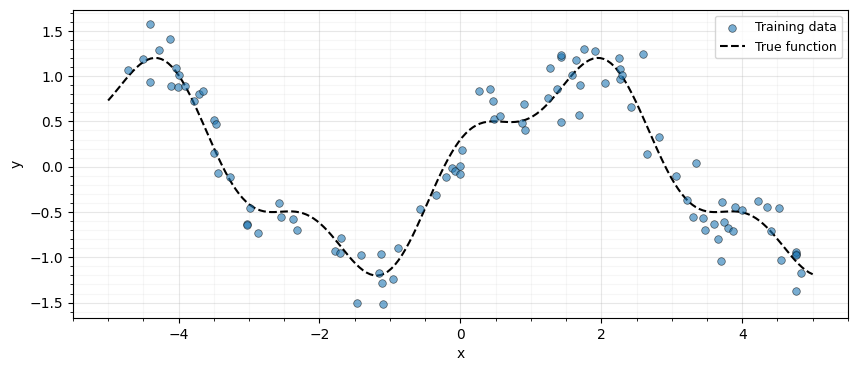

In [2]:
key = jax.random.PRNGKey(42)
n_train = 100
n_test = 200

# Training data
key, subkey = jax.random.split(key)
X_train = jnp.sort(jax.random.uniform(subkey, (n_train,), minval=-5.0, maxval=5.0))
f_true = jnp.sin(X_train) + 0.3 * jnp.cos(3.0 * X_train)
key, subkey = jax.random.split(key)
y_train = f_true + 0.2 * jax.random.normal(subkey, (n_train,))

# Test data
X_test = jnp.linspace(-5.0, 5.0, n_test)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(
    X_train,
    y_train,
    s=30,
    edgecolors="k",
    linewidths=0.5,
    alpha=0.6,
    label="Training data",
    zorder=5,
)
ax.plot(
    X_test,
    jnp.sin(X_test) + 0.3 * jnp.cos(3.0 * X_test),
    "k--",
    lw=1.5,
    label="True function",
    zorder=4,
)
ax.set(xlabel="x", ylabel="y")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.show()

### Kernel and noise parameters

In [3]:
def rbf_kernel(x1, x2, lengthscale, variance):
    """RBF kernel matrix between two 1D input arrays."""
    sq_dist = (x1[:, None] - x2[None, :]) ** 2
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale**2)


# Kernel hyperparameters
lengthscale = 1.0
variance = 1.0
noise_var = 0.04  # sigma^2

# Build the noisy kernel matrix K + sigma^2 I
K_train = rbf_kernel(X_train, X_train, lengthscale, variance)
K_noisy = K_train + noise_var * jnp.eye(n_train)

# Wrap as a lineax operator (PSD tag enables symmetric eigensolver)
K_op = lx.MatrixLinearOperator(K_noisy, lx.positive_semidefinite_tag)

print(f"Training points:  {n_train}")
print(f"Kernel matrix:    {K_noisy.shape}")

Training points:  100
Kernel matrix:    (100, 100)


## 3. Build LOVE cache

The `gaussx.love_cache` function runs a Lanczos iteration on the
kernel operator, producing a low-rank approximation of $\tilde{K}^{-1}$.
The result is a `LOVECache` containing:

- **Q** — orthonormal Lanczos basis, shape `(n, m)`
- **inv_eigvals** — reciprocal eigenvalues of the tridiagonal matrix, shape `(m,)`

In [4]:
cache = gaussx.love_cache(K_op, lanczos_order=50, key=jax.random.PRNGKey(0))

print("LOVECache fields:")
print(f"  Q shape:            {cache.Q.shape}")
print(f"  inv_eigvals shape:  {cache.inv_eigvals.shape}")

LOVECache fields:
  Q shape:            (100, 50)
  inv_eigvals shape:  (50,)


The Lanczos order $m = 50$ is half the matrix size here, but in
practice $m \ll n$ suffices. The cache can be reused for any number
of test points.

## 4. Fast predictive variance

For each test point $x_*$, we need the cross-covariance vector
$k_* = k(X, x_*)$ and the prior variance $k_{**} = k(x_*, x_*)$.
LOVE gives us the quadratic form $k_*^\top \tilde{K}^{-1} k_*$
cheaply.

In [5]:
# Cross-covariance for all test points: shape (n_test, n_train)
K_cross = rbf_kernel(X_test, X_train, lengthscale, variance)

# Prior variance at test points (diagonal of K_**)
K_test_diag = variance * jnp.ones(n_test)

# LOVE variance: vmap over test points
love_quad = jax.vmap(lambda k_row: gaussx.love_variance(cache, k_row))(K_cross)
love_var = K_test_diag - love_quad

print(f"LOVE predictive variance: shape {love_var.shape}")

LOVE predictive variance: shape (200,)


### Compare against exact variance

We compute the exact predictive variance via a dense solve for
validation.

In [6]:
# Exact: k_** - k_*^T K^{-1} k_* via gaussx.solve
alpha_cross = jax.vmap(
    lambda k_row: gaussx.solve(K_op, k_row),
    in_axes=0,
)(K_cross)
exact_quad = jnp.sum(K_cross * alpha_cross, axis=1)
exact_var = K_test_diag - exact_quad

# Compare
max_err = jnp.max(jnp.abs(love_var - exact_var))
rel_err = jnp.max(jnp.abs(love_var - exact_var) / jnp.abs(exact_var + 1e-12))
print(f"Max absolute error:  {max_err:.2e}")
print(f"Max relative error:  {rel_err:.2e}")

Max absolute error:  1.89e-15
Max relative error:  4.88e-13


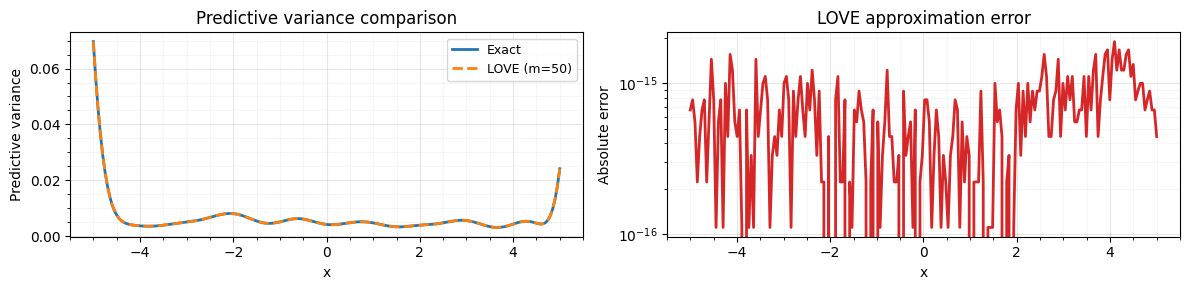

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(X_test, exact_var, label="Exact", linewidth=2, zorder=3)
axes[0].plot(X_test, love_var, "--", label="LOVE (m=50)", linewidth=2, zorder=3)
axes[0].set(
    xlabel="x", ylabel="Predictive variance", title="Predictive variance comparison"
)
axes[0].legend(fontsize=9)
axes[0].grid(True, which="major", alpha=0.3)
axes[0].grid(True, which="minor", alpha=0.1)
axes[0].minorticks_on()

axes[1].plot(X_test, jnp.abs(love_var - exact_var), color="tab:red", lw=2)
axes[1].set(xlabel="x", ylabel="Absolute error", title="LOVE approximation error")
axes[1].set_yscale("log")
axes[1].grid(True, which="major", alpha=0.3)
axes[1].grid(True, which="minor", alpha=0.1)
axes[1].minorticks_on()

plt.tight_layout()
plt.show()

### Speedup: vmap over many test points

The LOVE cache makes it trivial to compute variance for a batch
of test points via `jax.vmap`.

In [8]:
love_variance_batch = jax.jit(
    jax.vmap(lambda k_row: gaussx.love_variance(cache, k_row))
)

# Warm up JIT
_ = love_variance_batch(K_cross).block_until_ready()

# Time it
import timeit


n_repeats = 100
love_time = (
    timeit.timeit(
        lambda: love_variance_batch(K_cross).block_until_ready(), number=n_repeats
    )
    / n_repeats
)

# Compare with exact solve
exact_fn = jax.jit(jax.vmap(lambda k_row: gaussx.solve(K_op, k_row), in_axes=0))
_ = exact_fn(K_cross).block_until_ready()
exact_time = (
    timeit.timeit(lambda: exact_fn(K_cross).block_until_ready(), number=n_repeats)
    / n_repeats
)

print(f"LOVE variance ({n_test} points): {love_time * 1e3:.2f} ms")
print(f"Exact solve   ({n_test} points): {exact_time * 1e3:.2f} ms")
print(f"Speedup: {exact_time / love_time:.1f}x")

LOVE variance (200 points): 0.09 ms
Exact solve   (200 points): 0.59 ms
Speedup: 6.2x


## 5. LOO-CV via LOVE

Leave-one-out cross-validation computes, for each training point $i$,
the predictive mean and variance when that point is held out. The
classical identities (Rasmussen & Williams, 2006, Eq. 5.12) give:

$$\mu_{\text{LOO},i} = y_i - \frac{\alpha_i}{[\tilde{K}^{-1}]_{ii}},
\qquad
\sigma^2_{\text{LOO},i} = \frac{1}{[\tilde{K}^{-1}]_{ii}}$$

where $\alpha = \tilde{K}^{-1} y$. The diagonal of $\tilde{K}^{-1}$
is the expensive part; LOVE approximates it cheaply.

In [9]:
# Compute alpha = K^{-1} y (single solve, not LOO-specific)
alpha = gaussx.solve(K_op, y_train)

# Approximate K^{-1}_{ii} using LOVE cache:
# K^{-1}_{ii} = e_i^T Q diag(inv_eigvals) Q^T e_i
# = sum_j (Q_{ij}^2 * inv_eigvals_j)
K_inv_diag_love = jnp.sum(cache.Q**2 * cache.inv_eigvals[None, :], axis=1)
# Clamp diagonal to positive values to avoid negative variance
K_inv_diag_love = jnp.clip(K_inv_diag_love, a_min=1e-12)

# LOO predictive mean and variance
mu_loo = y_train - alpha / K_inv_diag_love
var_loo = 1.0 / K_inv_diag_love

print(f"LOO predictive mean:     shape {mu_loo.shape}")
print(f"LOO predictive variance: shape {var_loo.shape}")

LOO predictive mean:     shape (100,)
LOO predictive variance: shape (100,)


### LOO log-predictive density

The LOO log-predictive density (LPD) is a standard model selection
criterion:

$$\text{LOO-LPD} = \sum_{i=1}^{n} \log p(y_i \mid X_{\setminus i},
  y_{\setminus i}) = -\frac{n}{2}\log(2\pi)
  - \frac{1}{2}\sum_{i=1}^{n}\left[\log \sigma^2_{\text{LOO},i}
  + \frac{(y_i - \mu_{\text{LOO},i})^2}{\sigma^2_{\text{LOO},i}}\right]$$

In [10]:
loo_lpd = -0.5 * n_train * jnp.log(2 * jnp.pi) - 0.5 * jnp.sum(
    jnp.log(var_loo) + (y_train - mu_loo) ** 2 / var_loo
)
print(f"LOO log-predictive density: {loo_lpd:.4f}")

LOO log-predictive density: -170.9582


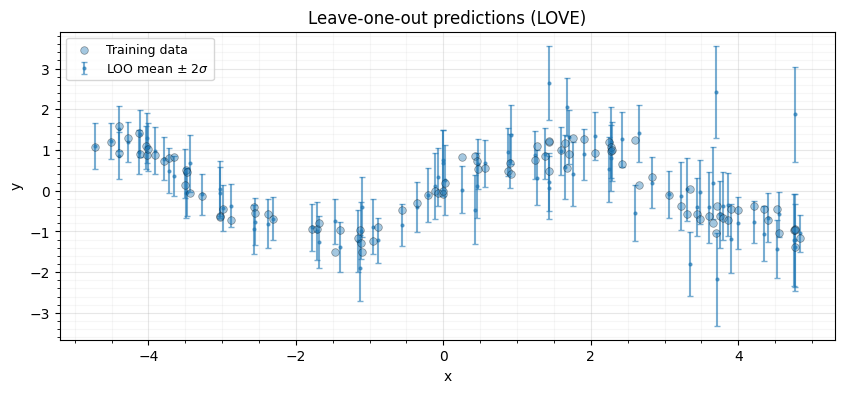

In [11]:
# Visualize LOO predictions
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(
    X_train,
    y_train,
    s=30,
    edgecolors="k",
    linewidths=0.5,
    alpha=0.4,
    label="Training data",
    zorder=5,
)
ax.errorbar(
    X_train,
    mu_loo,
    yerr=2 * jnp.sqrt(var_loo),
    fmt=".",
    markersize=4,
    alpha=0.6,
    capsize=2,
    label=r"LOO mean $\pm$ 2$\sigma$",
    zorder=3,
)
ax.set(xlabel="x", ylabel="y", title="Leave-one-out predictions (LOVE)")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.show()

## 6. Kronecker GP

When data lies on a 2D grid, the kernel matrix factorizes as a
Kronecker product $K = K_1 \otimes K_2$, reducing $O(N^3)$ to
$O(n_1^3 + n_2^3)$ where $N = n_1 n_2$.

gaussx provides `kronecker_mll` for the marginal log-likelihood and
`kronecker_posterior_predictive` for predictions.

### 2D grid problem

In [12]:
# Grid dimensions
n1, n2 = 10, 10
grid_shape = (n1, n2)
N = n1 * n2

# 1D grids
x1 = jnp.linspace(-3.0, 3.0, n1)
x2 = jnp.linspace(-3.0, 3.0, n2)

# True function on grid
X1, X2 = jnp.meshgrid(x1, x2, indexing="ij")
f_grid = jnp.sin(X1) * jnp.cos(X2)
y_grid = f_grid.ravel()

# Add noise
key, subkey = jax.random.split(key)
y_grid_noisy = y_grid + 0.1 * jax.random.normal(subkey, (N,))

# Build per-dimension kernel matrices
ls1, ls2 = 1.0, 1.0
var1, var2 = 1.0, 1.0
noise_var_grid = 0.01


def rbf_kernel_1d(x, lengthscale, var):
    """1D RBF kernel matrix."""
    sq_dist = (x[:, None] - x[None, :]) ** 2
    return var * jnp.exp(-0.5 * sq_dist / lengthscale**2)


K1 = rbf_kernel_1d(x1, ls1, var1)
K2 = rbf_kernel_1d(x2, ls2, var2)

# Wrap as lineax operators (PSD tag for symmetric eigensolvers)
K_factors = [
    lx.MatrixLinearOperator(K1, lx.positive_semidefinite_tag),
    lx.MatrixLinearOperator(K2, lx.positive_semidefinite_tag),
]

print(f"Grid: {n1} x {n2} = {N} points")
print(f"K1: {K1.shape}, K2: {K2.shape}")

Grid: 10 x 10 = 100 points
K1: (10, 10), K2: (10, 10)


### Marginal log-likelihood

In [13]:
mll = gaussx.kronecker_mll(K_factors, y_grid_noisy, noise_var_grid, grid_shape)
print(f"Kronecker MLL: {mll:.4f}")

Kronecker MLL: -4.0269


### Verify against dense GP

For this small grid we can also compute the dense MLL directly.

In [14]:
K_full = jnp.kron(K1, K2) + noise_var_grid * jnp.eye(N)
K_full_op = lx.MatrixLinearOperator(K_full, lx.positive_semidefinite_tag)

alpha_full = gaussx.solve(K_full_op, y_grid_noisy)
sign, logdet_full = jnp.linalg.slogdet(K_full)
mll_dense = -0.5 * (y_grid_noisy @ alpha_full + logdet_full + N * jnp.log(2 * jnp.pi))

print(f"Kronecker MLL: {mll:.4f}")
print(f"Dense MLL:     {mll_dense:.4f}")
print(f"Difference:    {jnp.abs(mll - mll_dense):.2e}")

Kronecker MLL: -4.0269
Dense MLL:     -4.0269
Difference:    1.71e-13


### Posterior predictions

We predict at a finer test grid using `kronecker_posterior_predictive`.
The function accepts per-dimension cross-covariance arrays and
test diagonal arrays.

In [15]:
# Test grid (finer)
n1_test, n2_test = 20, 20
x1_test = jnp.linspace(-3.0, 3.0, n1_test)
x2_test = jnp.linspace(-3.0, 3.0, n2_test)

# Per-dimension cross-covariances: (n_test_d, n_train_d)
K_cross_1 = rbf_kernel_1d(x1_test, ls1, var1)[:, :n1]  # (n1_test, n1)
K_cross_2 = rbf_kernel_1d(x2_test, ls2, var2)[:, :n2]  # (n2_test, n2)

# Fix: compute proper cross-covariance between test and train grids
K_cross_1 = var1 * jnp.exp(-0.5 * (x1_test[:, None] - x1[None, :]) ** 2 / ls1**2)
K_cross_2 = var2 * jnp.exp(-0.5 * (x2_test[:, None] - x2[None, :]) ** 2 / ls2**2)

K_cross_factors = [K_cross_1, K_cross_2]

# Per-dimension test diagonals: (n_test_d,)
K_test_diag_1 = var1 * jnp.ones(n1_test)
K_test_diag_2 = var2 * jnp.ones(n2_test)
K_test_diag_factors = [K_test_diag_1, K_test_diag_2]

# Posterior predictions
pred_mean, pred_var = gaussx.kronecker_posterior_predictive(
    K_factors,
    y_grid_noisy,
    noise_var_grid,
    grid_shape,
    K_cross_factors,
    K_test_diag_factors=K_test_diag_factors,
)

print(f"Posterior mean shape: {pred_mean.shape}")
print(f"Posterior var shape:  {pred_var.shape}")

Posterior mean shape: (400,)
Posterior var shape:  (400,)


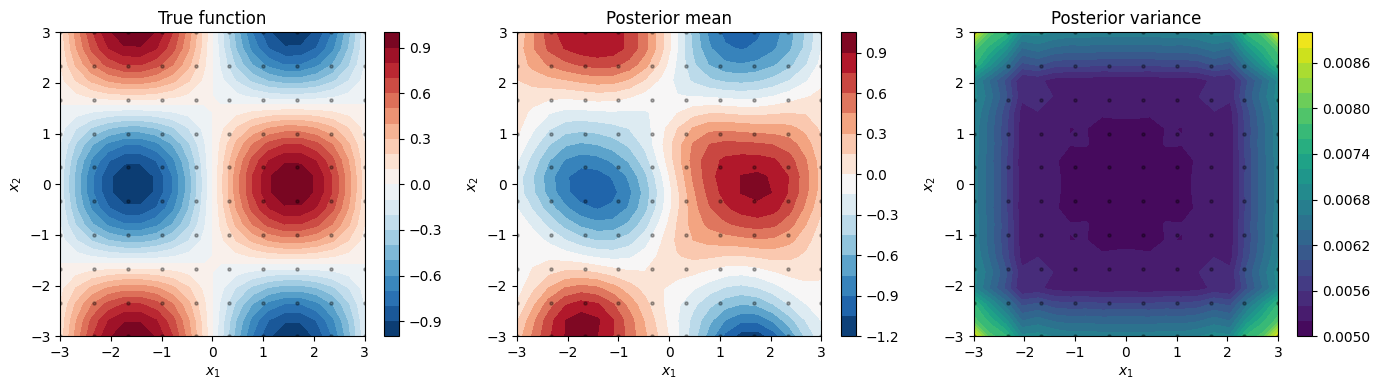

In [16]:
X1_test, X2_test = jnp.meshgrid(x1_test, x2_test, indexing="ij")
f_test_true = jnp.sin(X1_test) * jnp.cos(X2_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].contourf(X1_test, X2_test, f_test_true, levels=20, cmap="RdBu_r")
axes[0].set_title("True function")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(
    X1_test, X2_test, pred_mean.reshape(n1_test, n2_test), levels=20, cmap="RdBu_r"
)
axes[1].set_title("Posterior mean")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(
    X1_test, X2_test, pred_var.reshape(n1_test, n2_test), levels=20, cmap="viridis"
)
axes[2].set_title("Posterior variance")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set(xlabel="$x_1$", ylabel="$x_2$")
    ax.scatter(X1.ravel(), X2.ravel(), c="k", s=5, alpha=0.3, zorder=5)

plt.tight_layout()
plt.show()

## 7. Hyperparameter selection: LOO-CV vs MLL

We sweep over a range of lengthscales and compare two model selection
criteria:

- **Marginal log-likelihood (MLL)** — the standard Bayesian criterion
- **LOO log-predictive density** — approximated via LOVE

Both should favour similar lengthscales, but LOO-CV can be more robust
when the model is misspecified.

In [17]:
lengthscales = jnp.linspace(0.3, 3.0, 20)

mll_scores = []
loo_scores = []

for ls_val in lengthscales:
    ls_val = float(ls_val)

    # Build kernel matrix
    K_ls = rbf_kernel(X_train, X_train, ls_val, 1.0)
    K_ls_noisy = K_ls + noise_var * jnp.eye(n_train)
    K_ls_op = lx.MatrixLinearOperator(K_ls_noisy, lx.positive_semidefinite_tag)

    # MLL
    alpha_ls = gaussx.solve(K_ls_op, y_train)
    sign_ls, logdet_ls = jnp.linalg.slogdet(K_ls_noisy)
    mll_val = -0.5 * (y_train @ alpha_ls + logdet_ls + n_train * jnp.log(2 * jnp.pi))
    mll_scores.append(float(mll_val))

    # LOO-CV via LOVE
    cache_ls = gaussx.love_cache(K_ls_op, lanczos_order=50, key=jax.random.PRNGKey(0))
    K_inv_diag_ls = jnp.sum(cache_ls.Q**2 * cache_ls.inv_eigvals[None, :], axis=1)
    # Clamp diagonal to positive values to avoid negative variance
    K_inv_diag_ls = jnp.clip(K_inv_diag_ls, a_min=1e-12)
    mu_loo_ls = y_train - alpha_ls / K_inv_diag_ls
    var_loo_ls = 1.0 / K_inv_diag_ls
    loo_val = -0.5 * n_train * jnp.log(2 * jnp.pi) - 0.5 * jnp.sum(
        jnp.log(var_loo_ls) + (y_train - mu_loo_ls) ** 2 / var_loo_ls
    )
    loo_scores.append(float(loo_val))

mll_scores = jnp.array(mll_scores)
loo_scores = jnp.array(loo_scores)

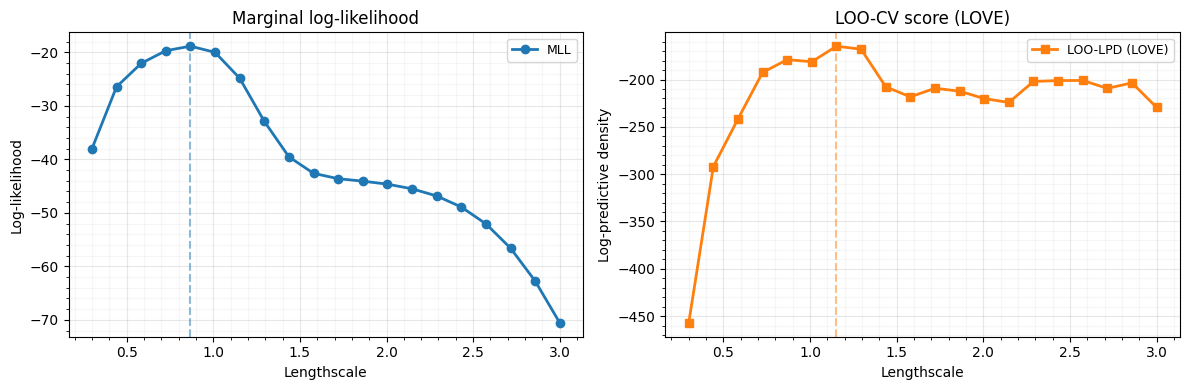

Best lengthscale (MLL):    0.87
Best lengthscale (LOO-CV): 1.15


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lengthscales, mll_scores, "o-", label="MLL", lw=2)
axes[0].axvline(
    lengthscales[jnp.argmax(mll_scores)], color="tab:blue", linestyle="--", alpha=0.5
)
axes[0].set(
    xlabel="Lengthscale", ylabel="Log-likelihood", title="Marginal log-likelihood"
)
axes[0].legend(fontsize=9)
axes[0].grid(True, which="major", alpha=0.3)
axes[0].grid(True, which="minor", alpha=0.1)
axes[0].minorticks_on()

axes[1].plot(
    lengthscales,
    loo_scores,
    "s-",
    color="tab:orange",
    label="LOO-LPD (LOVE)",
    lw=2,
)
axes[1].axvline(
    lengthscales[jnp.argmax(loo_scores)], color="tab:orange", linestyle="--", alpha=0.5
)
axes[1].set(
    xlabel="Lengthscale", ylabel="Log-predictive density", title="LOO-CV score (LOVE)"
)
axes[1].legend(fontsize=9)
axes[1].grid(True, which="major", alpha=0.3)
axes[1].grid(True, which="minor", alpha=0.1)
axes[1].minorticks_on()

plt.tight_layout()
plt.show()

best_ls_mll = float(lengthscales[jnp.argmax(mll_scores)])
best_ls_loo = float(lengthscales[jnp.argmax(loo_scores)])
print(f"Best lengthscale (MLL):    {best_ls_mll:.2f}")
print(f"Best lengthscale (LOO-CV): {best_ls_loo:.2f}")

## 8. Summary

| Method | Function | Cost |
|--------|----------|------|
| LOVE cache | `love_cache` | $O(nm)$ one-time |
| LOVE var | `love_variance` | $O(nm+m)$/point |
| LOO-CV | Cache diagonal | $O(nm)$ all pts |
| Kron MLL | `kronecker_mll` | $O(n_d^3)$ |
| Kron pred | `kronecker_posterior_predictive` | $O(n_d^3)$ |

**Key takeaways:**

- `love_cache` computes a Lanczos factorization once; `love_variance`
  reuses it for fast predictive variance at any test point.
- LOO-CV diagonals come for free from the LOVE cache -- no additional
  solves needed.
- Kronecker structure turns grid GPs from $O(N^3)$ into $O(\sum n_d^3)$.
- MLL and LOO-CV generally agree on hyperparameters, but LOO-CV
  provides a complementary, directly predictive criterion.

**References:**

- Pleiss, G., Gardner, J., Weinberger, K., & Wilson, A. G. (2018).
  Constant-time predictive distributions for Gaussian processes. *ICML*.
- Rasmussen, C. E. & Williams, C. K. I. (2006).
  *Gaussian Processes for Machine Learning*. MIT Press.